In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import charge_path, first_visualizer, normalize_string_columns, normalize_date_columns,prueba, identify_nulls, identify_outliers


In [2]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../output/catalog_film.csv'
df_original = charge_path(PATH)
df = df_original.copy()

In [3]:
first_visualizer(df)
normalize_string_columns(df)
normalize_date_columns(df)
identify_nulls(df)



              title     category  length rating language  total_inventory  \
0  academy dinosaur  documentary      86     PG  english                7   
1    ace goldfinger       horror      48      G  english                3   
2  adaptation holes  documentary      50  NC-17  english                4   
3  affair prejudice       horror     117      G  english                7   
4       african egg       family     130      G  english                3   

   total_rentals  
0             23  
1              7  
2             12  
3             23  
4             12  
El dataset tiene 7 columnas
El dataset tiene 958 filas/registros
-------------------------------
El dataset tiene 0 filas duplicadas.
-------------------------------
Suma de valores nulos por columna:
title              0
category           0
length             0
rating             0
language           0
total_inventory    0
total_rentals      0
dtype: int64
-------------------------------
Porcentaje de valores nulos po

Identificación de valores atípicos en columnas numéricas:
Columna: length, Número de outliers: 0


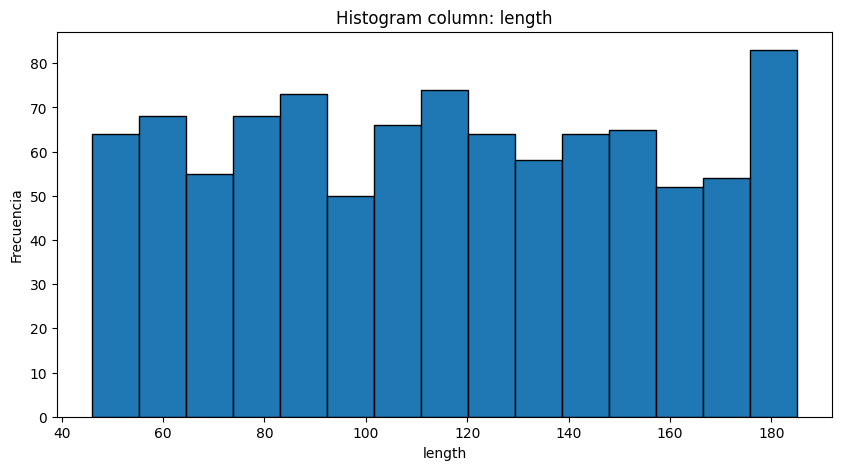

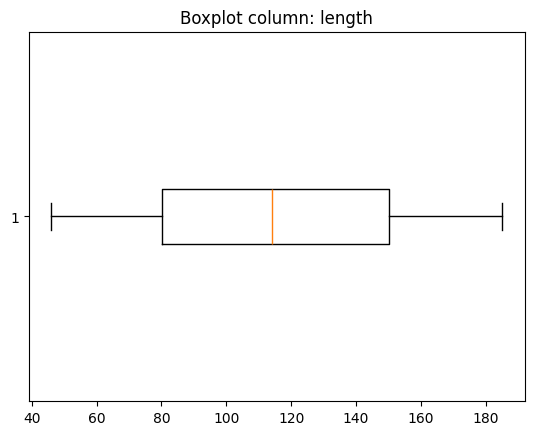

Columna: total_inventory, Número de outliers: 0


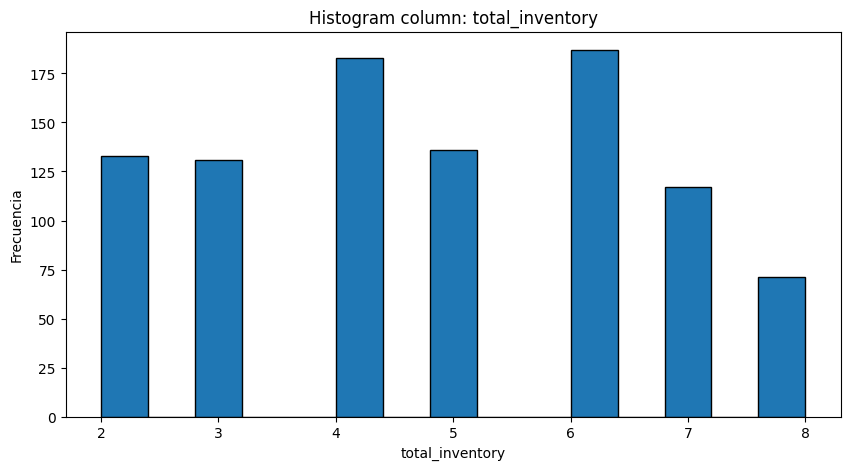

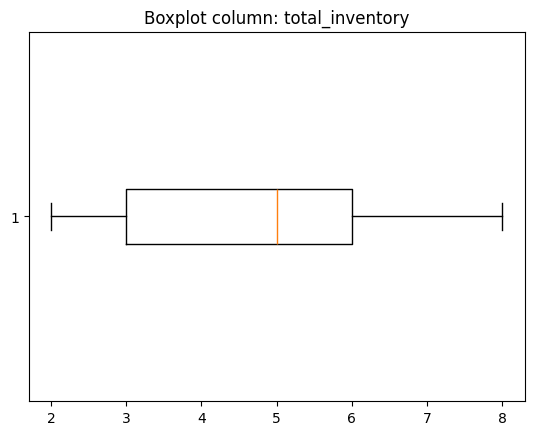

Columna: total_rentals, Número de outliers: 0


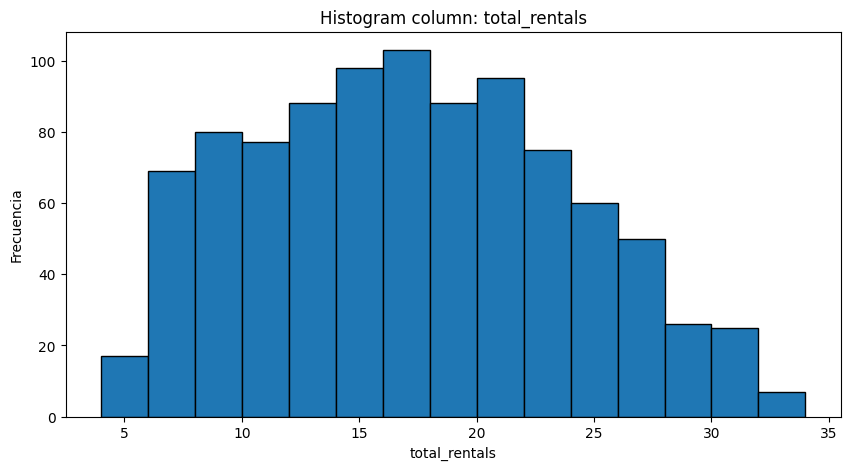

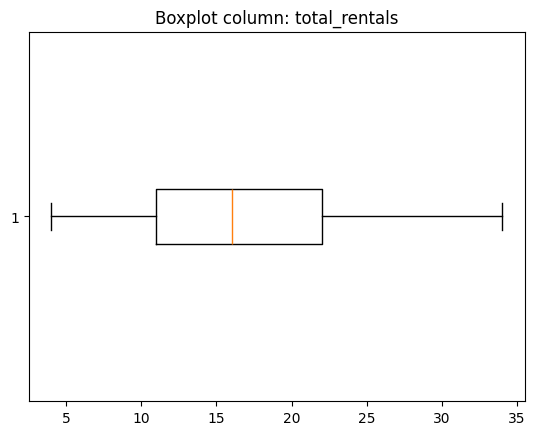

In [4]:
columns_numeric = df.select_dtypes("number").columns
columns_categorical = df.select_dtypes("object").columns

identify_outliers(df,columns_numeric,columns_categorical)

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            958 non-null    string
 1   category         958 non-null    string
 2   length           958 non-null    int64 
 3   rating           958 non-null    string
 4   language         958 non-null    string
 5   total_inventory  958 non-null    int64 
 6   total_rentals    958 non-null    int64 
dtypes: int64(3), string(4)
memory usage: 52.5 KB


En este caso podemos observar tango el el código como en la gráfica la ausencia de valores outliers

,title,category,length,rating,language,total_inventory,total_rentals
0,academy dinosaur,documentary,86,pg,english,7,23
1,ace goldfinger,horror,48,g,english,3,7
2,adaptation holes,documentary,50,nc17,english,4,12
3,affair prejudice,horror,117,g,english,7,23
4,african egg,family,130,g,english,3,12


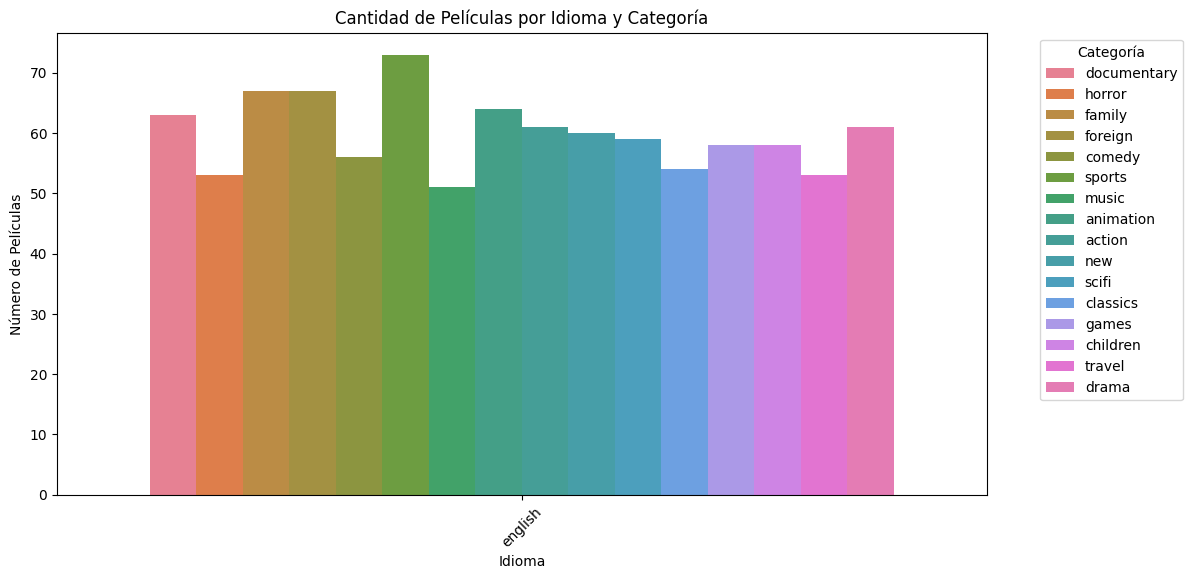

In [9]:
plt.figure(figsize=(12, 6))

# Usamos countplot porque cuenta automáticamente los registros
sns.countplot(data=df, x='language', hue='category')

plt.title('Cantidad de Películas por Idioma y Categoría')
plt.xlabel('Idioma')
plt.ylabel('Número de Películas')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left') # Mueve la leyenda fuera para que no estorbe
plt.xticks(rotation=45)
plt.show()

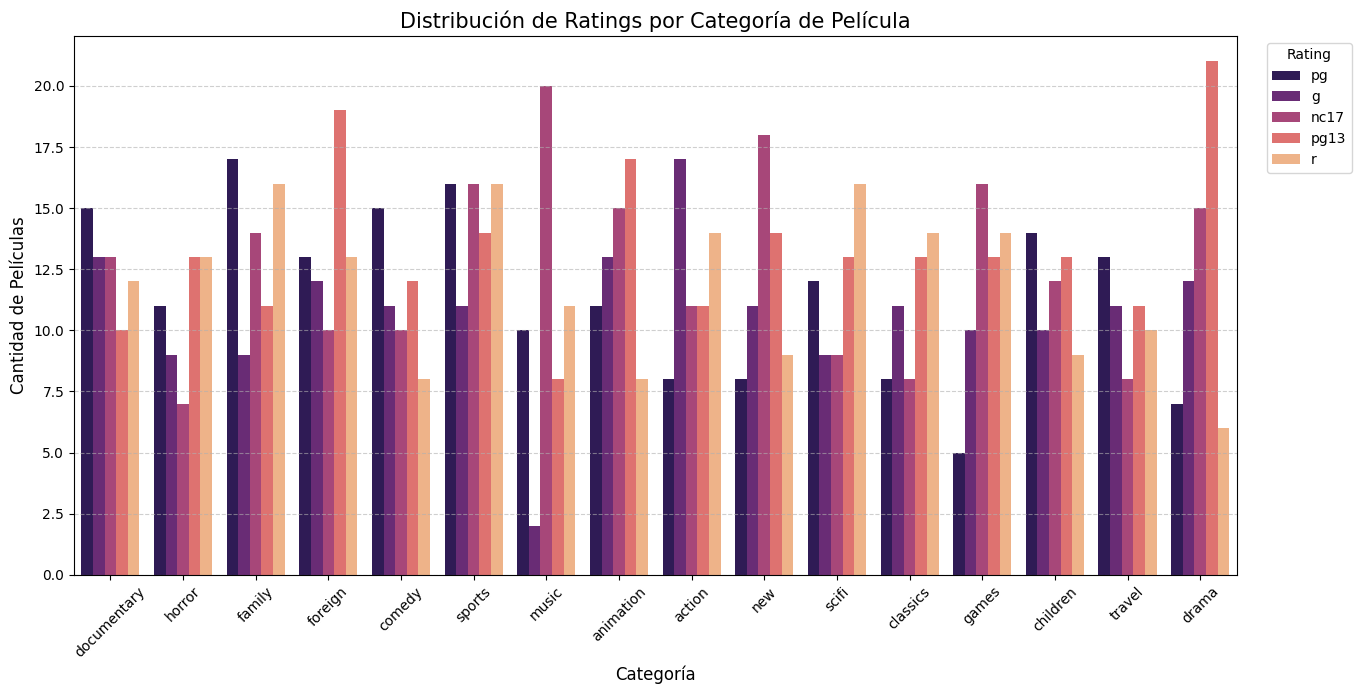

In [11]:
# Configuramos el tamaño de la figura (más ancha para que quepan todas las categorías)
plt.figure(figsize=(15, 7))

# Creamos el gráfico de barras
# x: Categoría, hue: Rating (colores por cada tipo de clasificación)
sns.countplot(data=df, x='category', hue='rating', palette='magma')

# Personalización de etiquetas
plt.title('Distribución de Ratings por Categoría de Película', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)

# Rotamos los nombres de las categorías 45 grados para que sean legibles
plt.xticks(rotation=45)

# Movemos la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6) # Una rejilla ligera para ayudar a leer los valores
plt.show()